In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
insurance = pd.read_csv('insurance.csv')
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

In [3]:
insurance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
insurance.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


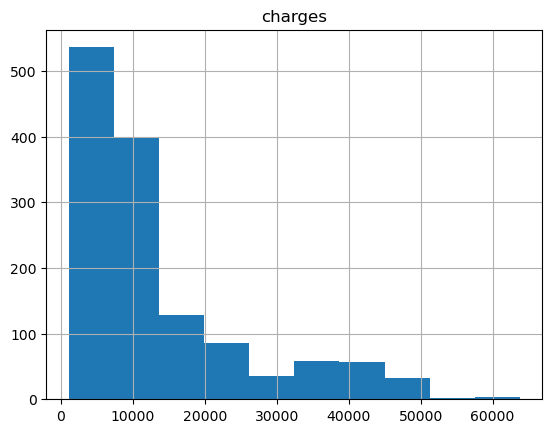

In [7]:
insurance.hist('charges')
plt.show()

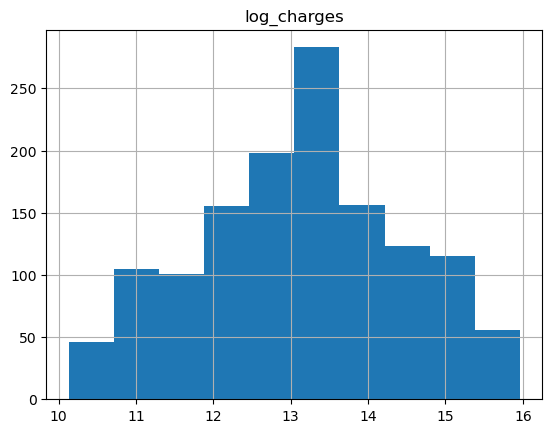

In [9]:
insurance['log_charges'] = np.log2(insurance['charges'])

insurance.hist('log_charges')
plt.show()

In [ ]:
numeric = insurance[['age', 'bmi', 'children', 'charges', 'log_charges']]

correlations = numeric.corr()
correlations

# may drop children because of low correlation

,age,bmi,children,charges,log_charges
age,1.000000,0.109272,0.042469,0.299008,0.527834
bmi,0.109272,1.000000,0.012759,0.198341,0.132669
children,0.042469,0.012759,1.000000,0.067998,0.161336
charges,0.299008,0.198341,0.067998,1.000000,0.892964
log_charges,0.527834,0.132669,0.161336,0.892964,1.000000


<Axes: >

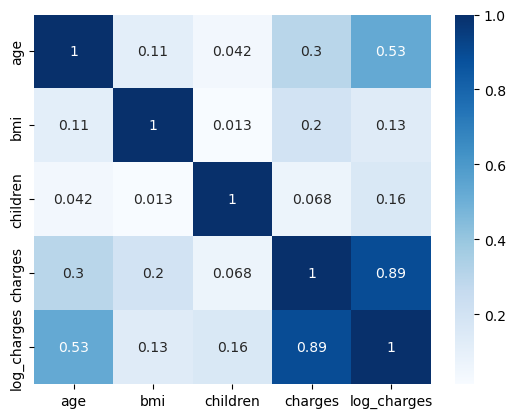

In [15]:
sns.heatmap(correlations, cmap="Blues", annot=True)

In [ ]:
sns.pairplot(numeric, kind='scatter', plot_kws={'alpha' : 0.4})

<Axes: title={'center': 'log_charges'}, xlabel='smoker'>

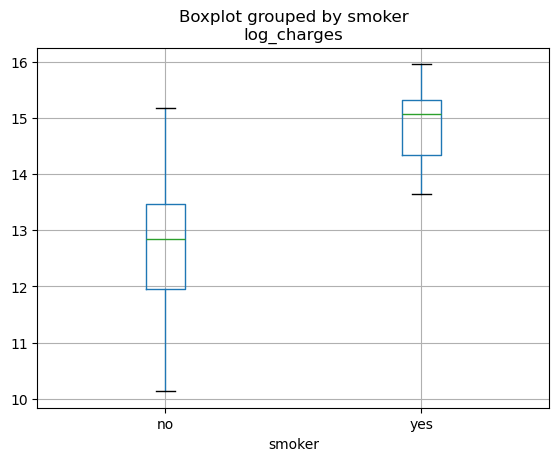

In [21]:
insurance.boxplot(column=['log_charges'], by='smoker')

# Building the model

In [23]:
insurance['is_smoker'] = (insurance['smoker'] == 'yes')  # encoding to numerical
X = insurance[['age', 'bmi', 'is_smoker']]  # dropped children because of low correlation
y = insurance['log_charges']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=42)


In [24]:
insurance_model = LinearRegression()
insurance_model.fit(X_train, y_train)
insurance_model.coef_

array([0.0508618 , 0.01563733, 2.23214787])

In [26]:
y_pred = insurance_model.predict(X_train)

In [29]:
train_mse_orig_scale = np.exp2(mean_squared_error(y_train, y_pred))
train_mse_orig_scale

np.float64(1.3640714326864813)

In [ ]:
train_r2 = r2_score(y_train, y_pred)
train_r2

#good predictor

0.743333600772825